In [3]:
# ==============================================================================
# CELL 1: Install Dependencies, Setup Paths & Download Artifacts
# ==============================================================================
import os
import sys

# Install required packages quietly in Kaggle environment
!pip install -q ultralytics easyocr timm

import zipfile
import urllib.request

# Resource URLs
RTDETR_WEIGHTS_URL = "https://storage.saifullahmnsur.dev/download/rtdetr_complete_artifacts/models/rtdetr_best.pt"
DATASET_URL = "https://storage.saifullahmnsur.dev/download/Photocard-fake-real-classification.zip"

# Working directory setup (Kaggle safe)
WORKING_DIR = "/kaggle/working"
WEIGHTS_PATH = os.path.join(WORKING_DIR, "rtdetr_best.pt")
ZIP_PATH = os.path.join(WORKING_DIR, "Photocard-fake-real-classification.zip")
EXTRACT_DIR = os.path.join(WORKING_DIR, "dataset_classification_raw")

os.makedirs(EXTRACT_DIR, exist_ok=True)
os.makedirs(os.path.join(WORKING_DIR, "export_bundle/models"), exist_ok=True)
os.makedirs(os.path.join(WORKING_DIR, "export_bundle/metrics"), exist_ok=True)
os.makedirs(os.path.join(WORKING_DIR, "export_bundle/plots"), exist_ok=True)

# 1. Download RT-DETR Weights
if not os.path.exists(WEIGHTS_PATH):
    print(f"[*] Downloading RT-DETR model weights from {RTDETR_WEIGHTS_URL}...")
    urllib.request.urlretrieve(RTDETR_WEIGHTS_URL, WEIGHTS_PATH)
    print("[+] Model weights downloaded!")

# 2. Download and Extract Classification Dataset
if not os.path.exists(ZIP_PATH):
    print(f"[*] Downloading classification dataset from {DATASET_URL}...")
    urllib.request.urlretrieve(DATASET_URL, ZIP_PATH)
    print("[+] Dataset downloaded!")

print(f"[*] Extracting dataset into '{EXTRACT_DIR}'...")
with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)

print("[★] Kaggle environment initialized & dataset ready.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.3/45.3 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 24.0 MB/s eta 0:00:00a 0:00:01
[*] Downloading RT-DETR model weights from https://storage.saifullahmnsur.dev/download/rtdetr_complete_artifacts/models/rtdetr_best.pt...
[+] Model weights downloaded!
[*] Downloading classification dataset from https://storage.saifullahmnsur.dev/download/Photocard-fake-real-classification.zip...
[+] Dataset downloaded!
[*] Extracting dataset into '/kaggle/working/dataset_classification_raw'...
[★] Kaggle environment initialized & dataset ready.


In [4]:
# ==============================================================================
# CELL 2: Initialize RT-DETR and EasyOCR Engine
# ==============================================================================
import torch
import easyocr
from ultralytics import RTDETR

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[*] Kaggle Computation Device: {device}")

# Load RT-DETR model weights
print(f"[*] Loading fine-tuned RT-DETR model from '{WEIGHTS_PATH}'...")
rtdetr_model = RTDETR(WEIGHTS_PATH)

print("[*] Initializing EasyOCR Engine (Bangla + English)...")
ocr_reader = easyocr.Reader(['bn', 'en'], gpu=torch.cuda.is_available())

# Exact 11-class mapping
CLASS_NAMES = {
    0: 'publisher', 1: 'publisher_logo', 2: 'image', 3: 'headline',
    4: 'text', 5: 'date', 6: 'url', 7: 'ad', 8: 'photocard',
    9: 'qr_code', 10: 'speaker'
}

num_gpus = torch.cuda.device_count()
print(f"[*] Total GPUs detected: {num_gpus}")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
[*] Kaggle Computation Device: cuda
[*] Loading fine-tuned RT-DETR model from '/kaggle/working/rtdetr_best.pt'...
[*] Initializing EasyOCR Engine (Bangla + English)...


Progress: |██████████████████████████████████████████████████| 100.0% Complete[*] Total GPUs detected: 2


In [5]:
# ==============================================================================
# CELL 3: RT-DETR Crop & EasyOCR Tabular Feature Extraction (With Error Handling)
# ==============================================================================
import cv2
import numpy as np
import glob
import pandas as pd

def extract_photocard_multimodal_features(image_path):
    """
    1. Uses RT-DETR to segment photocard layout regions.
    2. Crops 'headline', 'text', and 'speaker' regions with padding for EasyOCR.
    3. Returns a 6-feature tabular vector:
       [avg_ocr_conf, headline_char_cnt, text_char_cnt, speaker_present, publisher_present, date_present]
    """
    try:
        img_bgr = cv2.imread(image_path)
        if img_bgr is None:
            return [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]

        img_h, img_w, _ = img_bgr.shape
        
        # Predict bounding boxes
        results = rtdetr_model(img_bgr, conf=0.25, verbose=False)[0]
        
        detected_classes = set()
        headline_text, text_content = "", ""
        ocr_conf_scores = []
        
        for box in results.boxes:
            cls_id = int(box.cls[0].item())
            x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
            class_name = CLASS_NAMES.get(cls_id, f"class_{cls_id}")
            detected_classes.add(class_name)
            
            # Add 5px padding around bounding boxes
            pad = 5
            x1_pad, y1_pad = max(0, x1 - pad), max(0, y1 - pad)
            x2_pad, y2_pad = min(img_w, x2 + pad), min(img_h, y2 + pad)
            crop = img_bgr[y1_pad:y2_pad, x1_pad:x2_pad]
            
            if class_name in ['headline', 'text', 'speaker'] and crop.size > 0:
                ocr_res = ocr_reader.readtext(crop)
                extracted_str = " ".join([txt for _, txt, _ in ocr_res])
                conf_vals = [prob for _, _, prob in ocr_res]
                
                if conf_vals:
                    ocr_conf_scores.extend(conf_vals)
                if class_name == 'headline':
                    headline_text += " " + extracted_str
                elif class_name == 'text':
                    text_content += " " + extracted_str

        avg_ocr_conf = float(np.mean(ocr_conf_scores)) if ocr_conf_scores else 0.0
        headline_char_cnt = float(len(headline_text.strip()))
        text_char_cnt = float(len(text_content.strip()))
        speaker_present = 1.0 if 'speaker' in detected_classes else 0.0
        publisher_present = 1.0 if ('publisher' in detected_classes or 'publisher_logo' in detected_classes) else 0.0
        date_present = 1.0 if 'date' in detected_classes else 0.0

        return [avg_ocr_conf, headline_char_cnt, text_char_cnt, speaker_present, publisher_present, date_present]
    except Exception as e:
        print(f"[!] Error processing {image_path}: {e}")
        return [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]

# Gather dataset image paths
image_paths = sorted(glob.glob(f"{EXTRACT_DIR}/**/*.jpg", recursive=True) + 
                     glob.glob(f"{EXTRACT_DIR}/**/*.png", recursive=True) + 
                     glob.glob(f"{EXTRACT_DIR}/**/*.jpeg", recursive=True))

print(f"[*] Extracting layout + OCR features across {len(image_paths)} images...")

dataset_records = []
for idx, p in enumerate(image_paths):
    label = 0 if 'fake' in p.lower() else 1
    features = extract_photocard_multimodal_features(p)
    
    rec = {
        'image_path': p,
        'label': label,
        'avg_ocr_conf': features[0],
        'headline_char_cnt': features[1],
        'text_char_cnt': features[2],
        'speaker_present': features[3],
        'publisher_present': features[4],
        'date_present': features[5]
    }
    dataset_records.append(rec)
    
    if (idx + 1) % 25 == 0 or (idx + 1) == len(image_paths):
        print(f"  [+] Extracted features for {idx + 1}/{len(image_paths)} images")

df_multimodal = pd.DataFrame(dataset_records)
print(f"\n[★] Feature extraction complete! Successfully created df_multimodal with shape: {df_multimodal.shape}")

[*] Extracting layout + OCR features across 5756 images...
  [+] Extracted features for 25/5756 images
  [+] Extracted features for 50/5756 images
  [+] Extracted features for 75/5756 images
  [+] Extracted features for 100/5756 images
  [+] Extracted features for 125/5756 images
  [+] Extracted features for 150/5756 images
  [+] Extracted features for 175/5756 images
  [+] Extracted features for 200/5756 images
  [+] Extracted features for 225/5756 images
  [+] Extracted features for 250/5756 images
  [+] Extracted features for 275/5756 images
  [+] Extracted features for 300/5756 images
  [+] Extracted features for 325/5756 images
  [+] Extracted features for 350/5756 images
  [+] Extracted features for 375/5756 images
  [+] Extracted features for 400/5756 images
  [+] Extracted features for 425/5756 images
  [+] Extracted features for 450/5756 images
  [+] Extracted features for 475/5756 images
  [+] Extracted features for 500/5756 images
  [+] Extracted features for 525/5756 images

In [6]:
# ==============================================================================
# CELL 4: Train-Val-Test Stratified Split & Feature Scaler Export
# ==============================================================================
import json
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

feature_cols = ['avg_ocr_conf', 'headline_char_cnt', 'text_char_cnt', 'speaker_present', 'publisher_present', 'date_present']

# Stratified Split: 70% Train, 15% Validation, 15% Testing
train_df, temp_df = train_test_split(df_multimodal, test_size=0.30, random_state=42, stratify=df_multimodal['label'])
val_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=42, stratify=temp_df['label'])

print(f"[+] Dataset Split Counts -> Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

# Standardize tabular features
scaler = StandardScaler()
train_df[feature_cols] = scaler.fit_transform(train_df[feature_cols])
val_df[feature_cols] = scaler.transform(val_df[feature_cols])
test_df[feature_cols] = scaler.transform(test_df[feature_cols])

# Export scaler config for deployment
scaler_config = {
    "columns": feature_cols,
    "mean": scaler.mean_.tolist(),
    "scale": scaler.scale_.tolist()
}

scaler_path = os.path.join(WORKING_DIR, "export_bundle/metrics/ocr_scaler.json")
with open(scaler_path, "w") as f:
    json.dump(scaler_config, f, indent=4)

print(f"[+] Scaler config exported to '{scaler_path}'")

[+] Dataset Split Counts -> Train: 4029 | Val: 863 | Test: 864
[+] Scaler config exported to '/kaggle/working/export_bundle/metrics/ocr_scaler.json'


In [7]:
# ==============================================================================
# CELL 5: PyTorch Dataset & Data Loader Initialization
# ==============================================================================
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

class MultimodalPhotocardDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
        self.feature_cols = feature_cols

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row['image_path']).convert("RGB")
        
        if self.transform:
            image = self.transform(image)
            
        tabular_vec = torch.tensor(row[self.feature_cols].values.astype(np.float32))
        label = torch.tensor(row['label'], dtype=torch.float32)
        
        return image, tabular_vec, label

train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

eval_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_ds = MultimodalPhotocardDataset(train_df, transform=train_transforms)
val_ds = MultimodalPhotocardDataset(val_df, transform=eval_transforms)
test_ds = MultimodalPhotocardDataset(test_df, transform=eval_transforms)

BATCH_SIZE = 16
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

In [8]:
# ==============================================================================
# CELL 6: EfficientNet-B0 + MLP Classifier Training Engine
# ==============================================================================
import torch.nn as nn
import timm

class MultimodalLayoutClassifier(nn.Module):
    def __init__(self, num_tabular_features=6):
        super().__init__()
        # Vision Stream
        self.vision_backbone = timm.create_model('efficientnet_b0', pretrained=True, num_classes=0)
        
        # Tabular Stream
        self.tabular_head = nn.Sequential(
            nn.Linear(num_tabular_features, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.2)
        )
        
        # Late Fusion Classifier Head
        self.classifier = nn.Sequential(
            nn.Linear(1280 + 32, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1)
        )

    def forward(self, img_tensor, tabular_tensor):
        v_feat = self.vision_backbone(img_tensor)
        t_feat = self.tabular_head(tabular_tensor)
        fused = torch.cat((v_feat, t_feat), dim=1)
        return self.classifier(fused)

model = MultimodalLayoutClassifier(num_tabular_features=6).to(device)

# Wrap model if multiple GPUs are available
if torch.cuda.device_count() > 1:
    print(f"[+] Multi-GPU detected! Wrapping model with nn.DataParallel across {torch.cuda.device_count()} GPUs.")
    model = nn.DataParallel(model)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

EPOCHS = 10
history = {'epoch': [], 'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_loss = float('inf')

best_model_path = os.path.join(WORKING_DIR, "export_bundle/models/stage2_multimodal_best.pt")

print("[*] Starting Multimodal Layout Classifier Training...")
for epoch in range(1, EPOCHS + 1):
    model.train()
    train_loss, train_correct, total = 0.0, 0, 0
    for imgs, tabs, labels in train_loader:
        imgs, tabs, labels = imgs.to(device), tabs.to(device), labels.to(device).unsqueeze(1)
        
        optimizer.zero_grad()
        logits = model(imgs, tabs)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * imgs.size(0)
        preds = (torch.sigmoid(logits) >= 0.5).float()
        train_correct += (preds == labels).sum().item()
        total += labels.size(0)
        
    ep_train_loss = train_loss / total
    ep_train_acc = train_correct / total

    # Validation Pass
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, tabs, labels in val_loader:
            imgs, tabs, labels = imgs.to(device), tabs.to(device), labels.to(device).unsqueeze(1)
            logits = model(imgs, tabs)
            loss = criterion(logits, labels)
            
            val_loss += loss.item() * imgs.size(0)
            preds = (torch.sigmoid(logits) >= 0.5).float()
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    ep_val_loss = val_loss / val_total
    ep_val_acc = val_correct / val_total

    history['epoch'].append(epoch)
    history['train_loss'].append(ep_train_loss)
    history['val_loss'].append(ep_val_loss)
    history['train_acc'].append(ep_train_acc)
    history['val_acc'].append(ep_val_acc)

    if ep_val_loss < best_val_loss:
        best_val_loss = ep_val_loss
        torch.save(model.state_dict(), best_model_path)

    print(f"Epoch [{epoch:02d}/{EPOCHS:02d}] | Train Loss: {ep_train_loss:.4f} Acc: {ep_train_acc:.4f} | Val Loss: {ep_val_loss:.4f} Acc: {ep_val_acc:.4f}")

# Save history JSON
history_path = os.path.join(WORKING_DIR, "export_bundle/metrics/training_history.json")
with open(history_path, "w") as f:
    json.dump(history, f, indent=4)

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

[+] Multi-GPU detected! Wrapping model with nn.DataParallel across 2 GPUs.
[*] Starting Multimodal Layout Classifier Training...
Epoch [01/10] | Train Loss: 0.3010 Acc: 0.8853 | Val Loss: 0.2449 Acc: 0.8992
Epoch [02/10] | Train Loss: 0.1562 Acc: 0.9514 | Val Loss: 0.1477 Acc: 0.9571
Epoch [03/10] | Train Loss: 0.1304 Acc: 0.9571 | Val Loss: 0.1411 Acc: 0.9502
Epoch [04/10] | Train Loss: 0.1172 Acc: 0.9685 | Val Loss: 0.1275 Acc: 0.9618
Epoch [05/10] | Train Loss: 0.1153 Acc: 0.9680 | Val Loss: 0.1491 Acc: 0.9537
Epoch [06/10] | Train Loss: 0.0916 Acc: 0.9715 | Val Loss: 0.1263 Acc: 0.9537
Epoch [07/10] | Train Loss: 0.0547 Acc: 0.9868 | Val Loss: 0.1399 Acc: 0.9641
Epoch [08/10] | Train Loss: 0.0769 Acc: 0.9789 | Val Loss: 0.1026 Acc: 0.9676
Epoch [09/10] | Train Loss: 0.1274 Acc: 0.9645 | Val Loss: 0.2039 Acc: 0.9119
Epoch [10/10] | Train Loss: 0.1344 Acc: 0.9595 | Val Loss: 0.1136 Acc: 0.9618


In [10]:
!pip install onnxscript

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 722.0/722.0 kB 11.9 MB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.8/166.8 kB 14.4 MB/s eta 0:00:00


In [13]:
# ==============================================================================
# CELL 7: Test Set Evaluation & ONNX Model Export (State Dict Key Fix)
# ==============================================================================
import os
import json
import numpy as np
import torch
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# 1. Unwrap model if it was wrapped in DataParallel
raw_model = model.module if isinstance(model, torch.nn.DataParallel) else model

# 2. Load checkpoint and strip 'module.' prefix if present
state_dict = torch.load(best_model_path)
new_state_dict = {}
for k, v in state_dict.items():
    name = k[7:] if k.startswith('module.') else k  # remove `module.`
    new_state_dict[name] = v

raw_model.load_state_dict(new_state_dict)
raw_model.eval()

# 3. Evaluate on unseen Test Set
test_y_true, test_y_probs = [], []

with torch.no_grad():
    for imgs, tabs, labels in test_loader:
        imgs, tabs = imgs.to(device), tabs.to(device)
        logits = raw_model(imgs, tabs)
        probs = torch.sigmoid(logits).cpu().numpy().flatten()
        
        test_y_probs.extend(probs)
        test_y_true.extend(labels.numpy().flatten())

test_y_true = np.array(test_y_true)
test_y_probs = np.array(test_y_probs)
test_y_pred = (test_y_probs >= 0.5).astype(int)

test_acc = (test_y_pred == test_y_true).mean()
test_auc = roc_auc_score(test_y_true, test_y_probs)

test_metrics = {
    'test_accuracy': float(test_acc),
    'test_auc': float(test_auc),
    'y_true': test_y_true.tolist(),
    'y_probs': test_y_probs.tolist()
}

test_res_path = os.path.join(WORKING_DIR, "export_bundle/metrics/test_results.json")
with open(test_res_path, "w") as f:
    json.dump(test_metrics, f, indent=4)

print("\n" + "="*50)
print("             UNSEEN TEST SET PERFORMANCE")
print("="*50)
print(f"Test Accuracy Score: {test_acc:.4f}")
print(f"Test ROC-AUC Score:  {test_auc:.4f}")
print("\nClassification Report:")
print(classification_report(test_y_true, test_y_pred, target_names=['FAKE', 'REAL']))
print("="*50)

# 4. Export ONNX using unwrapped CPU model
print("[*] Exporting unwrapped model to ONNX format...")
raw_model_cpu = raw_model.cpu()
raw_model_cpu.eval()

dummy_img = torch.randn(1, 3, 224, 224)
dummy_tabular = torch.randn(1, 6)
onnx_path = os.path.join(WORKING_DIR, "export_bundle/models/photocard_classifier.onnx")

torch.onnx.export(
    raw_model_cpu, 
    (dummy_img, dummy_tabular), 
    onnx_path,
    export_params=True, 
    opset_version=18,
    do_constant_folding=True,
    input_names=['image_input', 'tabular_input'],
    output_names=['logits'],
    dynamic_axes={
        'image_input': {0: 'batch_size'},
        'tabular_input': {0: 'batch_size'},
        'logits': {0: 'batch_size'}
    },
    dynamo=False
)

print(f"[★] ONNX Model successfully exported to: {onnx_path}")


             UNSEEN TEST SET PERFORMANCE
Test Accuracy Score: 0.9664
Test ROC-AUC Score:  0.9891

Classification Report:
              precision    recall  f1-score   support

        FAKE       0.98      0.95      0.96       387
        REAL       0.96      0.98      0.97       477

    accuracy                           0.97       864
   macro avg       0.97      0.96      0.97       864
weighted avg       0.97      0.97      0.97       864

[*] Exporting unwrapped model to ONNX format...


/tmp/ipykernel_58/3966460547.py:71: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(


[★] ONNX Model successfully exported to: /kaggle/working/export_bundle/models/photocard_classifier.onnx


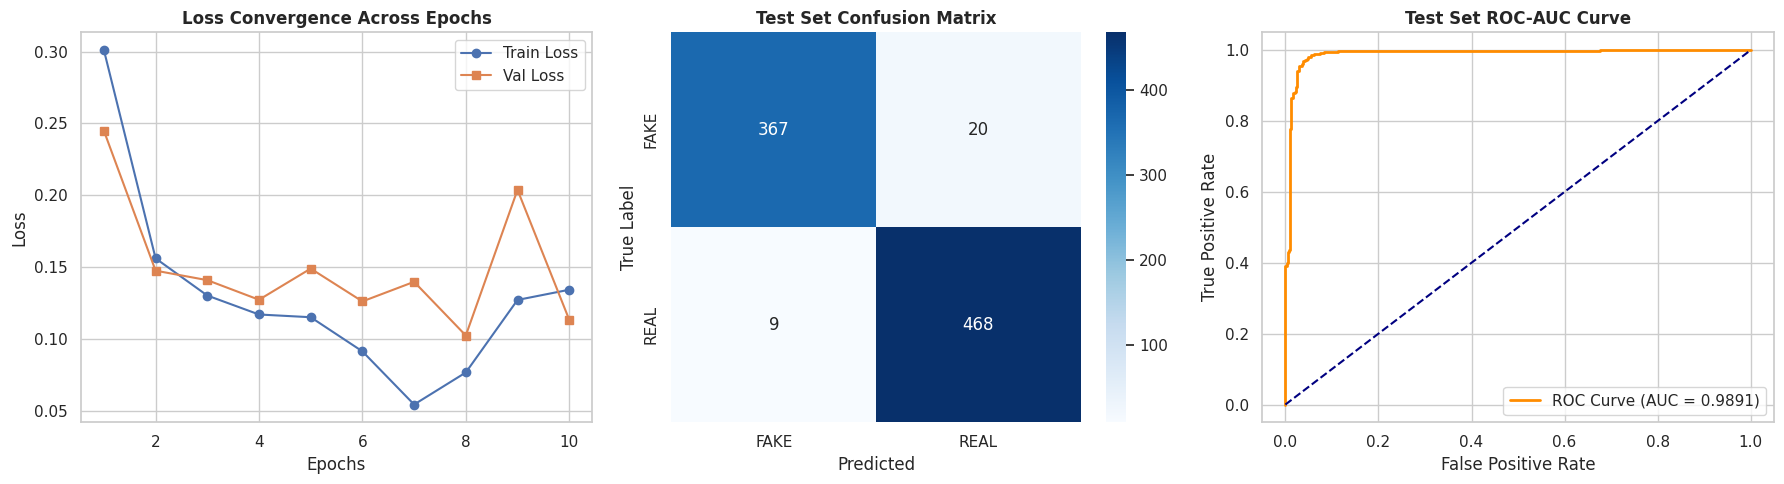

[★] Multimodal Analytics plot saved to: /kaggle/working/export_bundle/plots/03_multimodal_dashboard.png


In [14]:
# ==============================================================================
# CELL 8: Analytics Visual Plot Dashboard
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Training & Validation Curves
axes[0].plot(history['epoch'], history['train_loss'], label='Train Loss', marker='o')
axes[0].plot(history['epoch'], history['val_loss'], label='Val Loss', marker='s')
axes[0].set_title('Loss Convergence Across Epochs', fontweight='bold')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].legend()

# 2. Confusion Matrix
cm = confusion_matrix(test_y_true, test_y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['FAKE', 'REAL'], yticklabels=['FAKE', 'REAL'])
axes[1].set_title('Test Set Confusion Matrix', fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True Label')

# 3. ROC-AUC Curve
fpr, tpr, _ = roc_curve(test_y_true, test_y_probs)
axes[2].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {test_auc:.4f})')
axes[2].plot([0, 1], [0, 1], color='navy', linestyle='--')
axes[2].set_title('Test Set ROC-AUC Curve', fontweight='bold')
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].legend(loc="lower right")

plt.tight_layout()
plot_path = os.path.join(WORKING_DIR, "export_bundle/plots/03_multimodal_dashboard.png")
plt.savefig(plot_path, dpi=300)
plt.show()

print(f"[★] Multimodal Analytics plot saved to: {plot_path}")

In [15]:
# ==============================================================================
# CELL 9: Zip Export Bundle and Upload to Server
# ==============================================================================
import requests

ZIP_FILENAME = "multimodal_classifier_artifacts.zip"
EXPORT_DIR = os.path.join(WORKING_DIR, "export_bundle")
SERVER_UPLOAD_URL = "https://storage.saifullahmnsur.dev/upload"

print(f"[*] Archiving artifact bundle into '{ZIP_FILENAME}'...")
with zipfile.ZipFile(ZIP_FILENAME, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, dirs, files in os.walk(EXPORT_DIR):
        for file in files:
            file_path = os.path.join(root, file)
            arcname = os.path.relpath(file_path, EXPORT_DIR)
            zipf.write(file_path, arcname)

zip_size = os.path.getsize(ZIP_FILENAME) / (1024 * 1024)
print(f"[*] Archive created! Size: {zip_size:.2f} MB")

print(f"[*] Uploading artifacts to server at {SERVER_UPLOAD_URL}...")
try:
    with open(ZIP_FILENAME, 'rb') as f:
        files = {'file': (ZIP_FILENAME, f, 'application/zip')}
        response = requests.post(SERVER_UPLOAD_URL, files=files, timeout=300)
        
    if response.status_code == 200:
        print("[★] Upload Completed Successfully!")
        try:
            print("Server Response:", response.json())
        except Exception:
            print("Server Response:", response.text)
    else:
        print(f"[!] Upload failed with status code {response.status_code}: {response.text}")
except Exception as e:
    print(f"[!] Connection error during upload: {e}")

[*] Archiving artifact bundle into 'multimodal_classifier_artifacts.zip'...
[*] Archive created! Size: 29.45 MB
[*] Uploading artifacts to server at https://storage.saifullahmnsur.dev/upload...
[★] Upload Completed Successfully!
Server Response: {'status': 'success', 'filename': 'multimodal_classifier_artifacts.zip', 'download_url': '/download/multimodal_classifier_artifacts.zip'}


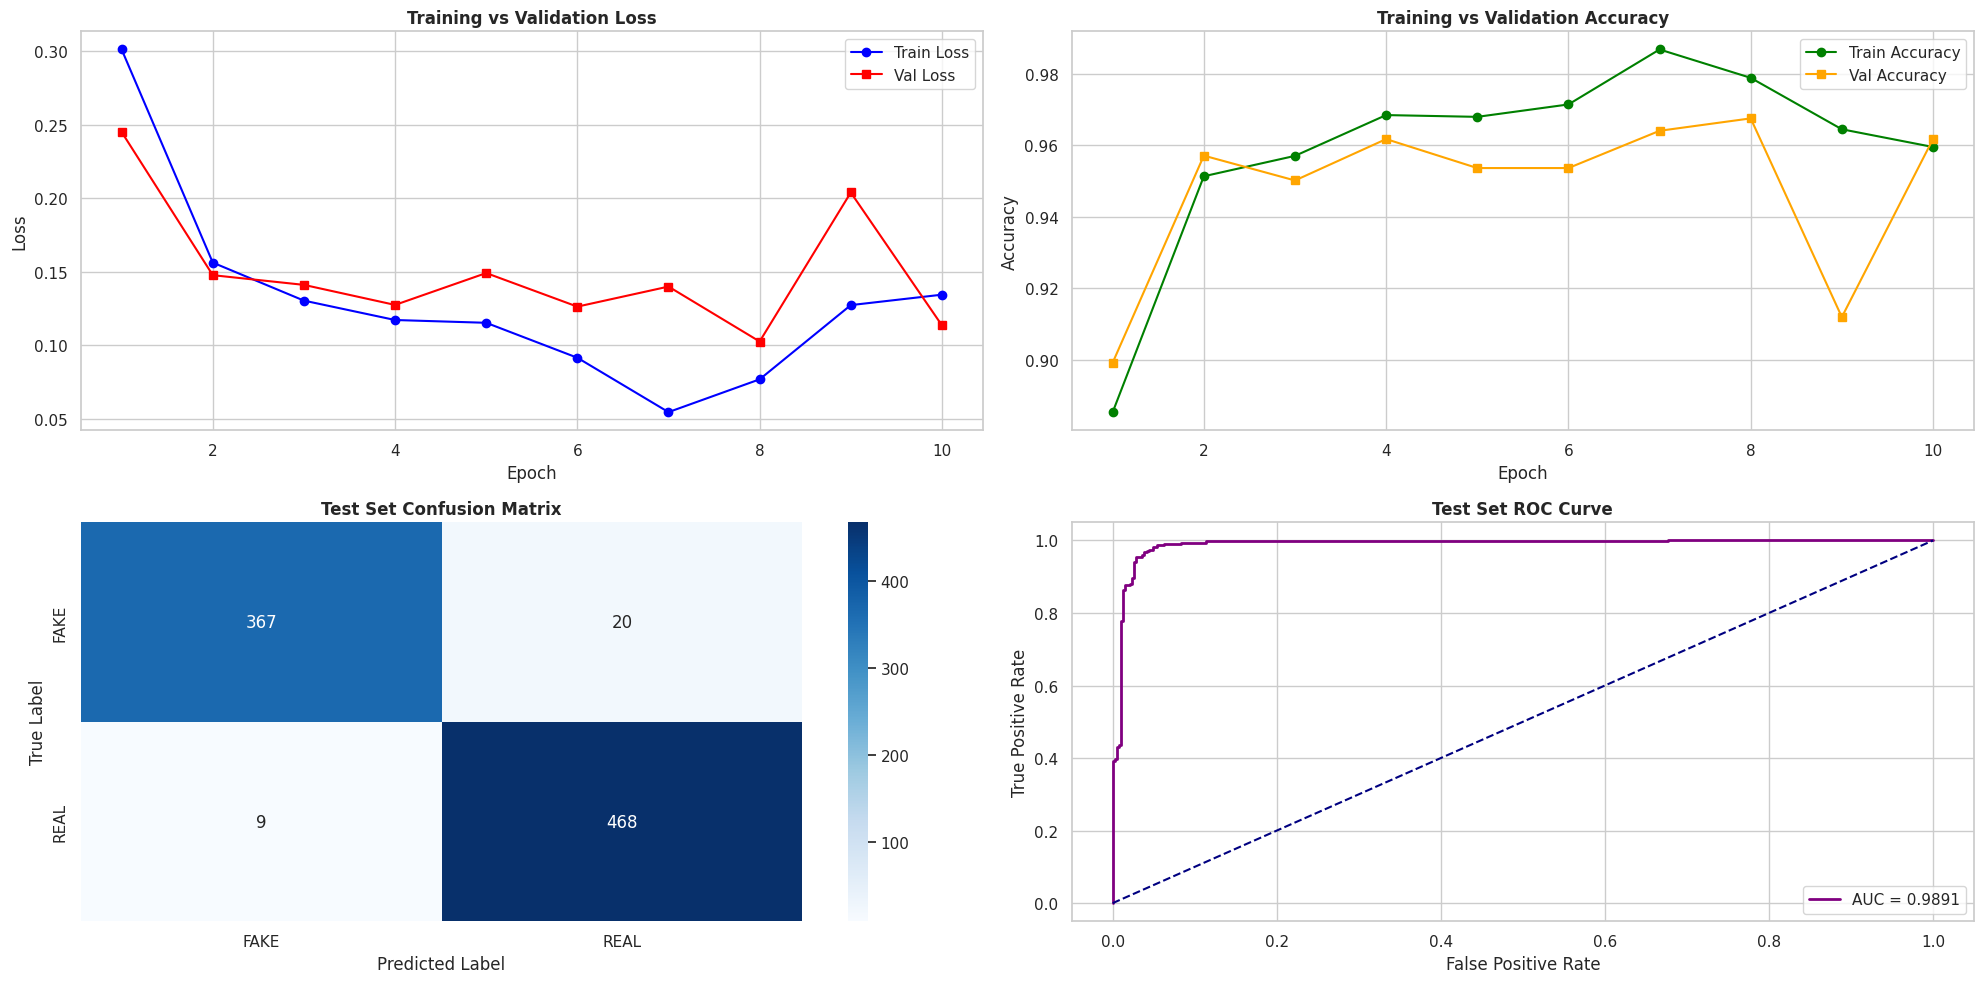

[★] Full analytics dashboard exported to: /kaggle/working/export_bundle/plots/03_full_analytics_dashboard.png


In [16]:
# ==============================================================================
# CELL 9: Detailed Visualization Dashboard (Training History + Output Visuals)
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os

# Load history
with open(os.path.join(WORKING_DIR, "export_bundle/metrics/training_history.json"), "r") as f:
    history = json.load(f)

sns.set_theme(style="whitegrid")
fig = plt.figure(figsize=(20, 10))

# 1. Training & Validation Loss (History)
ax1 = plt.subplot(2, 2, 1)
ax1.plot(history['epoch'], history['train_loss'], label='Train Loss', color='blue', marker='o')
ax1.plot(history['epoch'], history['val_loss'], label='Val Loss', color='red', marker='s')
ax1.set_title('Training vs Validation Loss', fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()

# 2. Training & Validation Accuracy (History)
ax2 = plt.subplot(2, 2, 2)
ax2.plot(history['epoch'], history['train_acc'], label='Train Accuracy', color='green', marker='o')
ax2.plot(history['epoch'], history['val_acc'], label='Val Accuracy', color='orange', marker='s')
ax2.set_title('Training vs Validation Accuracy', fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()

# 3. Confusion Matrix
ax3 = plt.subplot(2, 2, 3)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax3,
            xticklabels=['FAKE', 'REAL'], yticklabels=['FAKE', 'REAL'])
ax3.set_title('Test Set Confusion Matrix', fontweight='bold')
ax3.set_xlabel('Predicted Label')
ax3.set_ylabel('True Label')

# 4. ROC-AUC Curve
ax4 = plt.subplot(2, 2, 4)
ax4.plot(fpr, tpr, color='purple', lw=2, label=f'AUC = {test_auc:.4f}')
ax4.plot([0, 1], [0, 1], color='navy', linestyle='--')
ax4.set_title('Test Set ROC Curve', fontweight='bold')
ax4.set_xlabel('False Positive Rate')
ax4.set_ylabel('True Positive Rate')
ax4.legend(loc="lower right")

plt.tight_layout()
save_path = os.path.join(WORKING_DIR, "export_bundle/plots/03_full_analytics_dashboard.png")
plt.savefig(save_path, dpi=300)
plt.show()

print(f"[★] Full analytics dashboard exported to: {save_path}")

[*] Visualizing random batch from Test Set (Green = Correct, Red = Incorrect):


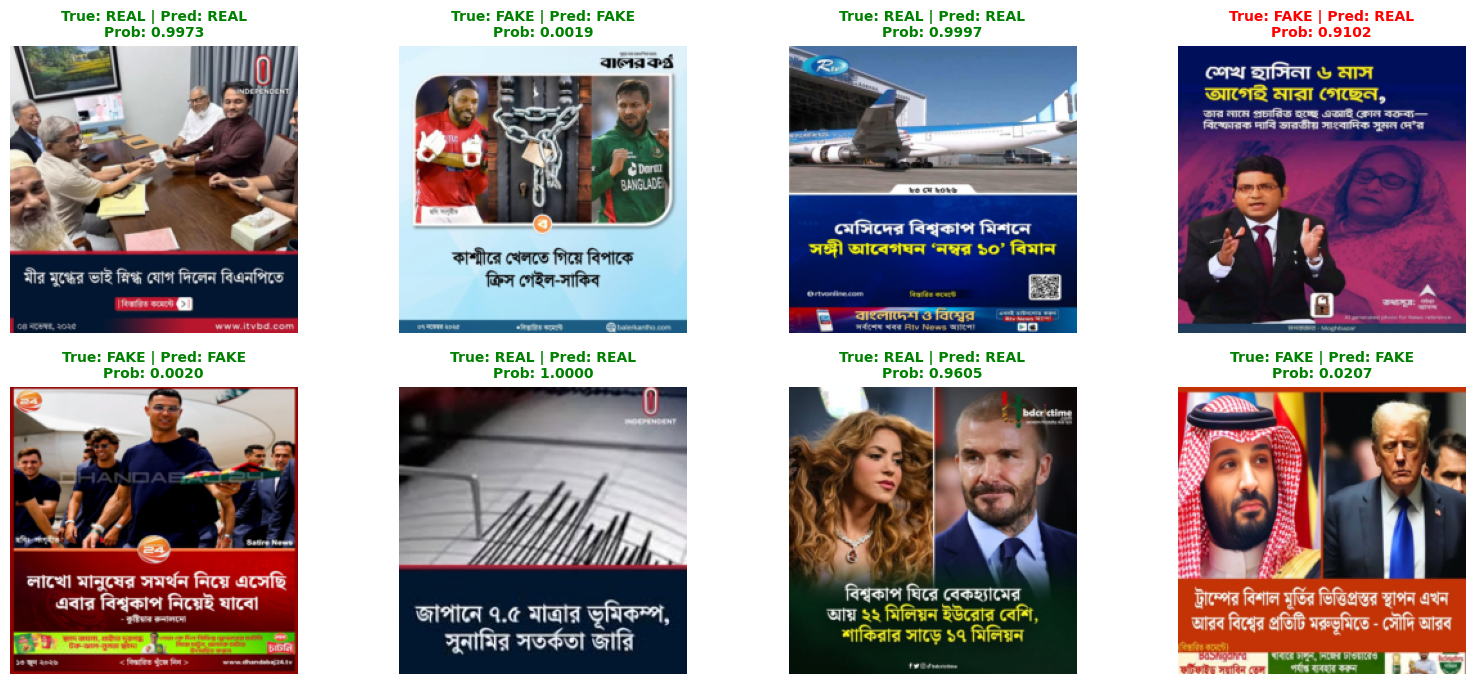

In [18]:
# ==============================================================================
# CELL 10: Visualize Test Batch Predictions (Device Sync Fixed)
# ==============================================================================
import torch
import numpy as np
import matplotlib.pyplot as plt

def visualize_predictions(loader, model_to_use, num_images=8):
    # Ensure model is on active device
    eval_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model_to_use = model_to_use.to(eval_device)
    model_to_use.eval()
    
    # Grab a single batch
    images, tabs, labels = next(iter(loader))
    images = images.to(eval_device)
    tabs = tabs.to(eval_device)
    
    with torch.no_grad():
        logits = model_to_use(images, tabs)
        probs = torch.sigmoid(logits).cpu().numpy().flatten()
        preds = (probs >= 0.5).astype(int)
    
    plt.figure(figsize=(16, 7))
    display_cnt = min(num_images, len(images))
    
    for i in range(display_cnt):
        plt.subplot(2, 4, i + 1)
        
        # Un-normalize image back to RGB range [0, 1] for visual display
        img = images[i].cpu().permute(1, 2, 0).numpy()
        img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
        img = np.clip(img, 0, 1)
        
        plt.imshow(img)
        
        true_lbl = "REAL" if int(labels[i].item()) == 1 else "FAKE"
        pred_lbl = "REAL" if preds[i] == 1 else "FAKE"
        
        is_correct = (preds[i] == int(labels[i].item()))
        title_color = 'green' if is_correct else 'red'
        
        plt.title(f"True: {true_lbl} | Pred: {pred_lbl}\nProb: {probs[i]:.4f}", 
                  color=title_color, fontsize=10, fontweight='bold')
        plt.axis('off')
        
    plt.tight_layout()
    plt.show()

print("[*] Visualizing random batch from Test Set (Green = Correct, Red = Incorrect):")
visualize_predictions(test_loader, raw_model)